In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.colors import LogNorm
import re

In [2]:
archivo_x = "perfil_flujo_x_ycte.out"
archivo_y = "perfil_flujo_y_xcte.out"

x_c = 0.0
y_c = 0.0

rx = 1.0
ry = 1.6

y_linea = 0.0
x_linea = 0.0

def leer_perfil_1d(archivo):
    datos = []
    leyendo = False

    with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            l = linea.lower()

            if "lower" in l and "upper" in l and "#" in l:
                leyendo = True
                continue

            if leyendo:
                if linea.strip() == "" or linea.strip().startswith("#") or "sum over" in l:
                    if len(datos) > 0:
                        break
                    continue

                partes = linea.split()

                try:
                    nums = [float(p.replace("D", "E")) for p in partes]
                except ValueError:
                    continue

                if len(nums) >= 4:
                    datos.append(nums)

    datos = np.array(datos)

    if datos.size == 0:
        raise ValueError(f"No pude leer datos numéricos en {archivo}")

    bordes_min = datos[:, 0]
    bordes_max = datos[:, 1]
    centro = 0.5 * (bordes_min + bordes_max)
    valor = datos[:, 2]
    err_rel = datos[:, 3]

    return centro, valor, err_rel

x, flujo_x, err_x = leer_perfil_1d(archivo_x)
y, flujo_y, err_y = leer_perfil_1d(archivo_y)

print("Rango leído del perfil horizontal:")
print(f"x = {x.min():.3f} a {x.max():.3f} cm")

print("\nRango leído del perfil vertical:")
print(f"y = {y.min():.3f} a {y.max():.3f} cm")

print("\nRango geométrico del pouch:")
print(f"x = {x_c - rx:.3f} a {x_c + rx:.3f} cm")
print(f"y = {y_c - ry:.3f} a {y_c + ry:.3f} cm")

Rango leído del perfil horizontal:
x = -2.975 a 2.975 cm

Rango leído del perfil vertical:
y = -2.975 a 2.975 cm

Rango geométrico del pouch:
x = -1.000 a 1.000 cm
y = -1.600 a 1.600 cm


In [3]:
if abs(y_linea - y_c) <= ry:
    dx = rx * np.sqrt(1 - ((y_linea - y_c) / ry) ** 2)
    x_pouch_min = x_c - dx
    x_pouch_max = x_c + dx
else:
    x_pouch_min = np.nan
    x_pouch_max = np.nan

if abs(x_linea - x_c) <= rx:
    dy = ry * np.sqrt(1 - ((x_linea - x_c) / rx) ** 2)
    y_pouch_min = y_c - dy
    y_pouch_max = y_c + dy
else:
    y_pouch_min = np.nan
    y_pouch_max = np.nan

print("Tramo del perfil horizontal y = 0 dentro del pouch:")
print(f"x = {x_pouch_min:.3f} a {x_pouch_max:.3f} cm")

print("\nTramo del perfil vertical x = 0 dentro del pouch:")
print(f"y = {y_pouch_min:.3f} a {y_pouch_max:.3f} cm")

Tramo del perfil horizontal y = 0 dentro del pouch:
x = -1.000 a 1.000 cm

Tramo del perfil vertical x = 0 dentro del pouch:
y = -1.600 a 1.600 cm


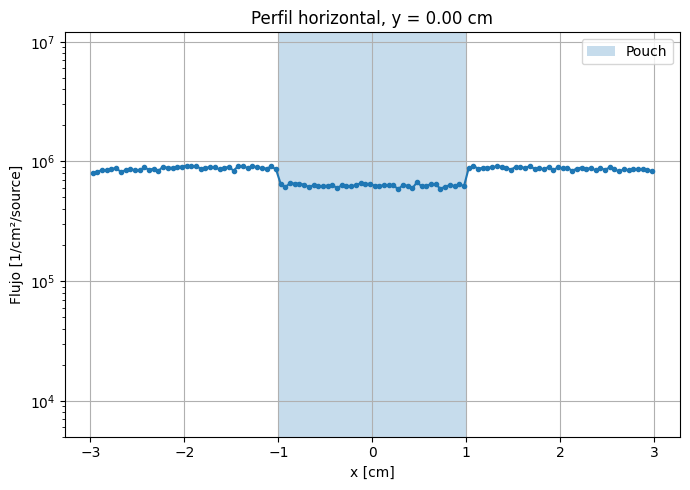

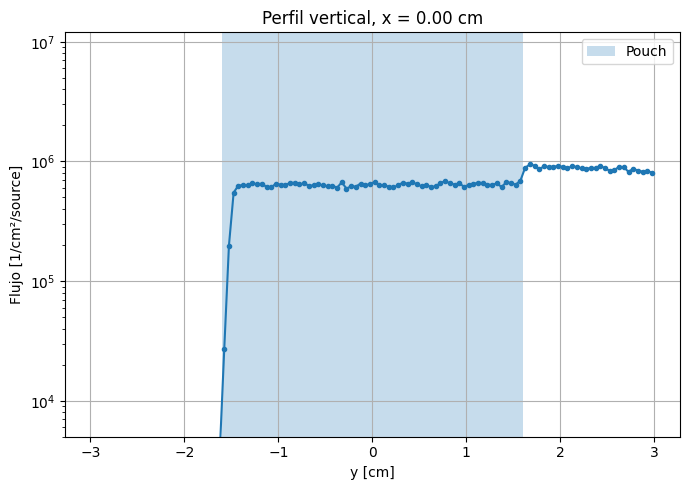

In [4]:
plt.figure(figsize=(7, 5))
plt.plot(x, flujo_x, marker="o", markersize=3)
plt.yscale("log")

if not np.isnan(x_pouch_min):
    plt.axvspan(x_pouch_min, x_pouch_max, alpha=0.25, label="Pouch")

plt.ylim(5e3, 1.2e7)
plt.xlabel("x [cm]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title(f"Perfil horizontal, y = {y_linea:.2f} cm")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(y, flujo_y, marker="o", markersize=3)
plt.yscale("log")

if not np.isnan(y_pouch_min):
    plt.axvspan(y_pouch_min, y_pouch_max, alpha=0.25, label="Pouch")

plt.ylim(5e3, 1.2e7)
plt.xlabel("y [cm]")
plt.ylabel("Flujo [1/cm²/source]")
plt.title(f"Perfil vertical, x = {x_linea:.2f} cm")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

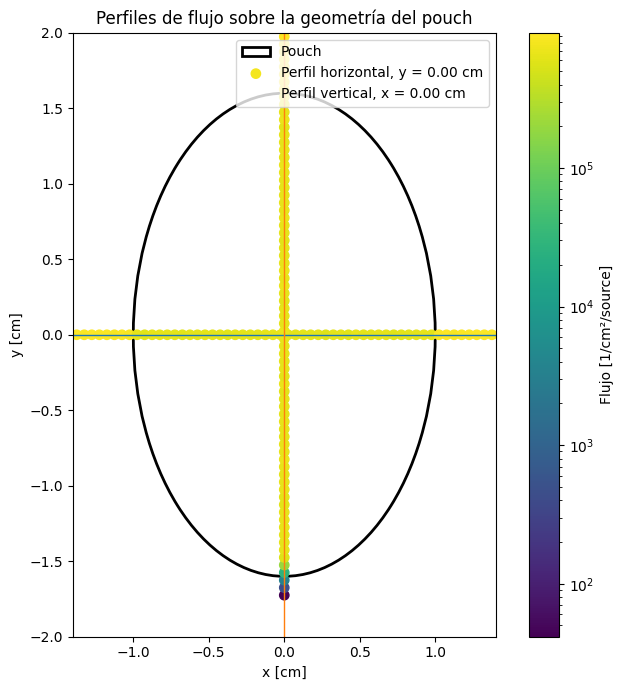

In [5]:
flujos_positivos = np.concatenate([flujo_x[flujo_x > 0], flujo_y[flujo_y > 0]])

vmin = np.min(flujos_positivos)
vmax = np.max(flujos_positivos)

fig, ax = plt.subplots(figsize=(7, 7))

pouch = Ellipse(
    (x_c, y_c),
    width=2 * rx,
    height=2 * ry,
    fill=False,
    linewidth=2,
    label="Pouch"
)

ax.add_patch(pouch)

sc1 = ax.scatter(
    x,
    np.full_like(x, y_linea),
    c=flujo_x,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    s=45,
    label=f"Perfil horizontal, y = {y_linea:.2f} cm"
)

sc2 = ax.scatter(
    np.full_like(y, x_linea),
    y,
    c=flujo_y,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    s=45,
    label=f"Perfil vertical, x = {x_linea:.2f} cm"
)

ax.plot(x, np.full_like(x, y_linea), linewidth=1)
ax.plot(np.full_like(y, x_linea), y, linewidth=1)

ax.set_aspect("equal")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Perfiles de flujo sobre la geometría del pouch")
ax.legend()

margen = 0.4
ax.set_xlim(x_c - rx - margen, x_c + rx + margen)
ax.set_ylim(y_c - ry - margen, y_c + ry + margen)

cbar = plt.colorbar(sc1, ax=ax)
cbar.set_label("Flujo [1/cm²/source]")

plt.tight_layout()
plt.show()